In [10]:
import pandas as pd 
import polars as pl
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

pl.Config.set_tbl_rows(50)
pl.Config.set_fmt_str_lengths(60)

# Tema visual
plt.style.use('default')

plt.rcParams.update({
    'figure.figsize': (5, 4),

    'axes.facecolor': '#FFFFFF',
    'figure.facecolor': '#FFFFFF',

    'axes.edgecolor': '#D0D7DE',

    'grid.color': '#E5E7EB',
    'grid.linestyle': '--',
    'grid.alpha': 0.8,

    'font.size': 10,
})

RANDOM_STATE = 42

In [11]:
features = pl.read_parquet("../data/interim/features_orig.parquet")
target = pl.read_parquet("../data/raw/target.parquet")

df =  features.with_columns(target['y'])

print(f'Filas: {df.height:,} | columnas: {df.width}')

Filas: 2,139,643 | columnas: 41


In [ ]:
TARGET = "y"

LEAKAGE_VARS = ['grade']

NUM = [ col for col, dtype in df.schema.items() if dtype.is_numeric() and col != 'y']

CAT = [col for col, dtype in df.schema.items() if dtype == pl.String and col != 'grade']

VARS = NUM + CAT

print(f"Variables de originación: {len(VARS)}  (numéricas: {len(NUM)}, categóricas: {len(CAT)})")


Variables de originación: 39  (numéricas: 29, categóricas: 10)


## Train and split

In [13]:
X = df[VARS]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(f"Train: filas: {X_train.height} & columnas: {X_train.width}")
print(f"Train: filas: {X_test.height} & columnas: {X_test.width}")
print(f"\nTrain Balance:{y_train.value_counts(normalize=True)}")
print(f"\nTest Balance:{y_test.value_counts(normalize=True)}")

Train: filas: 1711714 & columnas: 39
Train: filas: 427929 & columnas: 39

Train Balance:shape: (2, 2)
┌─────┬────────────┐
│ y   ┆ proportion │
│ --- ┆ ---        │
│ i64 ┆ f64        │
╞═════╪════════════╡
│ 1   ┆ 0.13073    │
│ 0   ┆ 0.86927    │
└─────┴────────────┘

Test Balance:shape: (2, 2)
┌─────┬────────────┐
│ y   ┆ proportion │
│ --- ┆ ---        │
│ i64 ┆ f64        │
╞═════╪════════════╡
│ 1   ┆ 0.13073    │
│ 0   ┆ 0.86927    │
└─────┴────────────┘


In [14]:
def missing_values(df, columnas):

    n_filas = df.height

    resumen_filas = []

    for col in df[columnas].columns:
        n_missing = df[col].null_count()
        resumen_filas.append({
            'columna' : col,
            'dtype':str(df.schema[col]),
            'n_unicos':df[col].n_unique(),
            'n_missing':n_missing,
            'pct_missing':round(n_missing/n_filas * 100,2)
        })

    resumen = (
        pl
        .DataFrame(resumen_filas)
        .sort('pct_missing', descending = True)
        .filter(pl.col('n_missing') > 0)
        )

    
    return   resumen

In [15]:
resumen_first = missing_values(X_train, VARS)
print(resumen_first)

shape: (12, 5)
┌────────────────────────────────────┬───────┬──────────┬───────────┬─────────────┐
│ columna                            ┆ dtype ┆ n_unicos ┆ n_missing ┆ pct_missing │
│ ---                                ┆ ---   ┆ ---      ┆ ---       ┆ ---         │
│ str                                ┆ str   ┆ i64      ┆ i64       ┆ f64         │
╞════════════════════════════════════╪═══════╪══════════╪═══════════╪═════════════╡
│ mths_since_recent_bankcard_delinq  ┆ Int64 ┆ 174      ┆ 1314766   ┆ 76.81       │
│ mths_since_recent_revol_delinq     ┆ Int64 ┆ 176      ┆ 1147320   ┆ 67.03       │
│ mths_since_last_delinq             ┆ Int64 ┆ 171      ┆ 872931    ┆ 51.0        │
│ mths_since_last_installment_acc_op ┆ Int64 ┆ 389      ┆ 724086    ┆ 42.3        │
│ num_open_trades_in_6mths           ┆ Int64 ┆ 19       ┆ 692516    ┆ 40.46       │
│ num_installment_acc_op_in_12mths   ┆ Int64 ┆ 19       ┆ 692516    ┆ 40.46       │
│ num_installment_acc_op_in_24mths   ┆ Int64 ┆ 30       ┆ 692

## Imputación de valores faltantes 

De acuerdo a nuestros analisis previo (EDA), estas variables `mths_since_last_delinq`, `mths_since_recent_bankcard_delinq`, `mths_since_recent_revol_delinq`. Estas variables no tienen nulo porque faltan datos, si no porque el usuario/prestatario nunca tuvo morosidad, es un indicador de un historial crediticio. Es de tipo Missing At random (MNAR) ya que no depende de otras variables.

Metodología de imputación:

1. Crearemos una variable binaria (indcador flag) (1/0) para los tres variables, estas variables nos indicarán si anterior a la imputación contaban con valores faltantes.

2. Reemplazaremos los valores nulos con un valor "Centinela" que nos distinga al resto de elementos. En este caso se aplicara del maximo de cada variable + 1000. Esto nos indicará que aquel usuario tiene un buen historial crediticio. 

In [16]:
months_since_vars = [
    "mths_since_last_delinq",
    "mths_since_recent_bankcard_delinq",
    "mths_since_recent_revol_delinq"
]

#Calculamos los sentinemas solo en train
sentinels = {}

for col in months_since_vars:
    max_value = X_train.select(pl.col(col).max()).item()
    sentinels[col] = int(max_value) + 1000

sentinels

{'mths_since_last_delinq': 1202,
 'mths_since_recent_bankcard_delinq': 1202,
 'mths_since_recent_revol_delinq': 1202}

In [17]:
def apply_sentinels(df, sentinels, columns):

    expressions = []
    # extend elementos directamente a la lista
    for col in columns:
        expressions.extend([
            pl.col(col)
            .is_null()
            .cast(pl.Int8)
            .alias(f"flag_never_{col}"),

            pl.col(col)
            .fill_null(sentinels[col])
            .alias(col)
        ])
    
    return df.with_columns(expressions)

In [18]:
#Aplicamos las imputaciones tanto en el train como en el test.
X_train = apply_sentinels(X_train, sentinels, months_since_vars)
X_test = apply_sentinels(X_test, sentinels, months_since_vars)

In [19]:
train_missing = missing_values(X_train, VARS)
print(train_missing)

test_missing = missing_values(X_test, VARS)
print(train_missing)

shape: (9, 5)
┌────────────────────────────────────┬───────┬──────────┬───────────┬─────────────┐
│ columna                            ┆ dtype ┆ n_unicos ┆ n_missing ┆ pct_missing │
│ ---                                ┆ ---   ┆ ---      ┆ ---       ┆ ---         │
│ str                                ┆ str   ┆ i64      ┆ i64       ┆ f64         │
╞════════════════════════════════════╪═══════╪══════════╪═══════════╪═════════════╡
│ mths_since_last_installment_acc_op ┆ Int64 ┆ 389      ┆ 724086    ┆ 42.3        │
│ num_open_trades_in_6mths           ┆ Int64 ┆ 19       ┆ 692516    ┆ 40.46       │
│ num_installment_acc_op_in_12mths   ┆ Int64 ┆ 19       ┆ 692516    ┆ 40.46       │
│ num_installment_acc_op_in_24mths   ┆ Int64 ┆ 30       ┆ 692516    ┆ 40.46       │
│ num_rev_trades_op_in_12mths        ┆ Int64 ┆ 29       ┆ 692516    ┆ 40.46       │
│ num_rev_trades_op_in_24mths        ┆ Int64 ┆ 49       ┆ 692516    ┆ 40.46       │
│ max_bal_owed                       ┆ Int64 ┆ 31787    ┆ 6925

- Ahora con las varianes que tienen terminologia inicial `num_` es un contador, la opción más conservadora es la imputación con 0. Ya que no se cuenta con un registro previo o sin actidad reciente antes de la fecha. 

- Por otro lado, las variables `mths_since_last_installment_acc_op`, `max_bal_owed` y `bal_to_cred_lim`, imputaremos con la mediana. 

Ademas, creamos variables flags binarias (0/1) para cada una de estas imputaciones. Finalmente, otra consideración a tener en cuenta probar estas imputaciones iniciales en un modelo inicial, y posteriormente probar cortando los datos > 2016. 

In [20]:
vintage_block_counts = [
    "num_inq", 
    "num_open_trades_in_6mths",
    "num_installment_acc_op_in_12mths",
    "num_installment_acc_op_in_24mths",
    "num_rev_trades_op_in_12mths",
    "num_rev_trades_op_in_24mths"
]

vintage_block_other = [
    "max_bal_owed",
    "bal_to_cred_lim",
    "mths_since_last_installment_acc_op"
    ]


medians_vintage ={
    col: X_train.select(pl.col(col).median()).item()
    for col in vintage_block_other
}

medians_vintage

{'max_bal_owed': 4403.0,
 'bal_to_cred_lim': 58.0,
 'mths_since_last_installment_acc_op': 13.0}

In [21]:
def imput_vintage_zero(df,columns):
    
    expressions = []

    for col in columns:
        expressions.extend([
            pl.col(col)
            .is_null()
            .cast(pl.Int8)
            .alias(f"Flag_missing_{col}"),


        pl.col(col)
        .fill_null(0)
        .alias(col)
        ]),

    return df.with_columns(expressions)

In [22]:
def imput_vintage_median(df,columns,median):

    expressions = []

    for col in columns:
        expressions.extend([
            pl.col(col)
            .is_null()
            .cast(pl.Int8)
            .alias(f"Flag_missing_{col}"),
        
        pl.col(col)
        .fill_null(median[col])
        .alias(col)
        ])

    return df.with_columns(expressions)
    

In [23]:
#Imputacion de variables tipo contadores
X_train = imput_vintage_zero(X_train, vintage_block_counts)
X_test = imput_vintage_zero(X_test, vintage_block_counts)

In [24]:
train_missing = missing_values(X_train, VARS)
print(train_missing)

test_missing = missing_values(X_test, VARS)
print(train_missing)

shape: (3, 5)
┌────────────────────────────────────┬───────┬──────────┬───────────┬─────────────┐
│ columna                            ┆ dtype ┆ n_unicos ┆ n_missing ┆ pct_missing │
│ ---                                ┆ ---   ┆ ---      ┆ ---       ┆ ---         │
│ str                                ┆ str   ┆ i64      ┆ i64       ┆ f64         │
╞════════════════════════════════════╪═══════╪══════════╪═══════════╪═════════════╡
│ mths_since_last_installment_acc_op ┆ Int64 ┆ 389      ┆ 724086    ┆ 42.3        │
│ max_bal_owed                       ┆ Int64 ┆ 31787    ┆ 692516    ┆ 40.46       │
│ bal_to_cred_lim                    ┆ Int64 ┆ 188      ┆ 692609    ┆ 40.46       │
└────────────────────────────────────┴───────┴──────────┴───────────┴─────────────┘
shape: (3, 5)
┌────────────────────────────────────┬───────┬──────────┬───────────┬─────────────┐
│ columna                            ┆ dtype ┆ n_unicos ┆ n_missing ┆ pct_missing │
│ ---                                ┆ ---   ┆ -

In [25]:
#Imputacion de variables tipo contadores
X_train = imput_vintage_median(X_train, vintage_block_other,medians_vintage)
X_test = imput_vintage_median(X_test, vintage_block_other, medians_vintage)

In [26]:
train_missing = missing_values(X_train, VARS)
print(train_missing)

test_missing = missing_values(X_test, VARS)
print(train_missing)

shape: (0, 5)
┌─────────┬───────┬──────────┬───────────┬─────────────┐
│ columna ┆ dtype ┆ n_unicos ┆ n_missing ┆ pct_missing │
│ ---     ┆ ---   ┆ ---      ┆ ---       ┆ ---         │
│ str     ┆ str   ┆ i64      ┆ i64       ┆ f64         │
╞═════════╪═══════╪══════════╪═══════════╪═════════════╡
└─────────┴───────┴──────────┴───────────┴─────────────┘
shape: (0, 5)
┌─────────┬───────┬──────────┬───────────┬─────────────┐
│ columna ┆ dtype ┆ n_unicos ┆ n_missing ┆ pct_missing │
│ ---     ┆ ---   ┆ ---      ┆ ---       ┆ ---         │
│ str     ┆ str   ┆ i64      ┆ i64       ┆ f64         │
╞═════════╪═══════╪══════════╪═══════════╪═════════════╡
└─────────┴───────┴──────────┴───────────┴─────────────┘


## Tratamiento de Outliers (winsorización)

Aplicaremos winsorizacion en percentiles extremos (p0.5/p99.5), para estas tres variables `total_credit_revolving_bal`, `annual_income`, `max_bal_owed`, descartando `used_credit_share`, porque estan dentro de los limites y estan en funcion del negocio igual que `funded_amnt`. 

In [27]:
outlier_candidates = ['annual_income', 
         'funded_amnt',
         'total_credit_revolving_bal',
        'max_bal_owed',
         'used_credit_share']


def iqr_outlier_summary(
    df: pl.DataFrame,
    cols: list[str],
    k: float = 1.5
) -> pl.DataFrame:
    """Resume outliers mediante el criterio IQR de Tukey."""

    rows = []

    for col in cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - k * iqr
        upper = q3 + k * iqr

        n_outliers = df.filter(
            (pl.col(col) < lower) |
            (pl.col(col) > upper)
        ).height

        rows.append({
            "variable": col,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "limite_inf": lower,
            "limite_sup": upper,
            "n_outliers": n_outliers,
            "pct_outliers": round(
                n_outliers / df.height * 100,
                2
            ),
        })

    return (
        pl.DataFrame(rows)
        .sort("pct_outliers", descending=True)
    )

iqr_summary = iqr_outlier_summary(X_train, outlier_candidates)

iqr_summary

variable,q1,q3,iqr,limite_inf,limite_sup,n_outliers,pct_outliers
str,f64,f64,f64,f64,f64,i64,f64
"""max_bal_owed""",3677.0,5127.0,1450.0,1502.0,7302.0,423648,24.75
"""total_credit_revolving_bal""",5985.0,20197.0,14212.0,-15333.0,41515.0,104019,6.08
"""annual_income""",47303.0,95000.0,47697.0,-24242.5,166545.5,80729,4.72
"""funded_amnt""",8000.0,20000.0,12000.0,-10000.0,38000.0,21752,1.27
"""used_credit_share""",31.7,69.4,37.7,-24.85,125.95,79,0.0


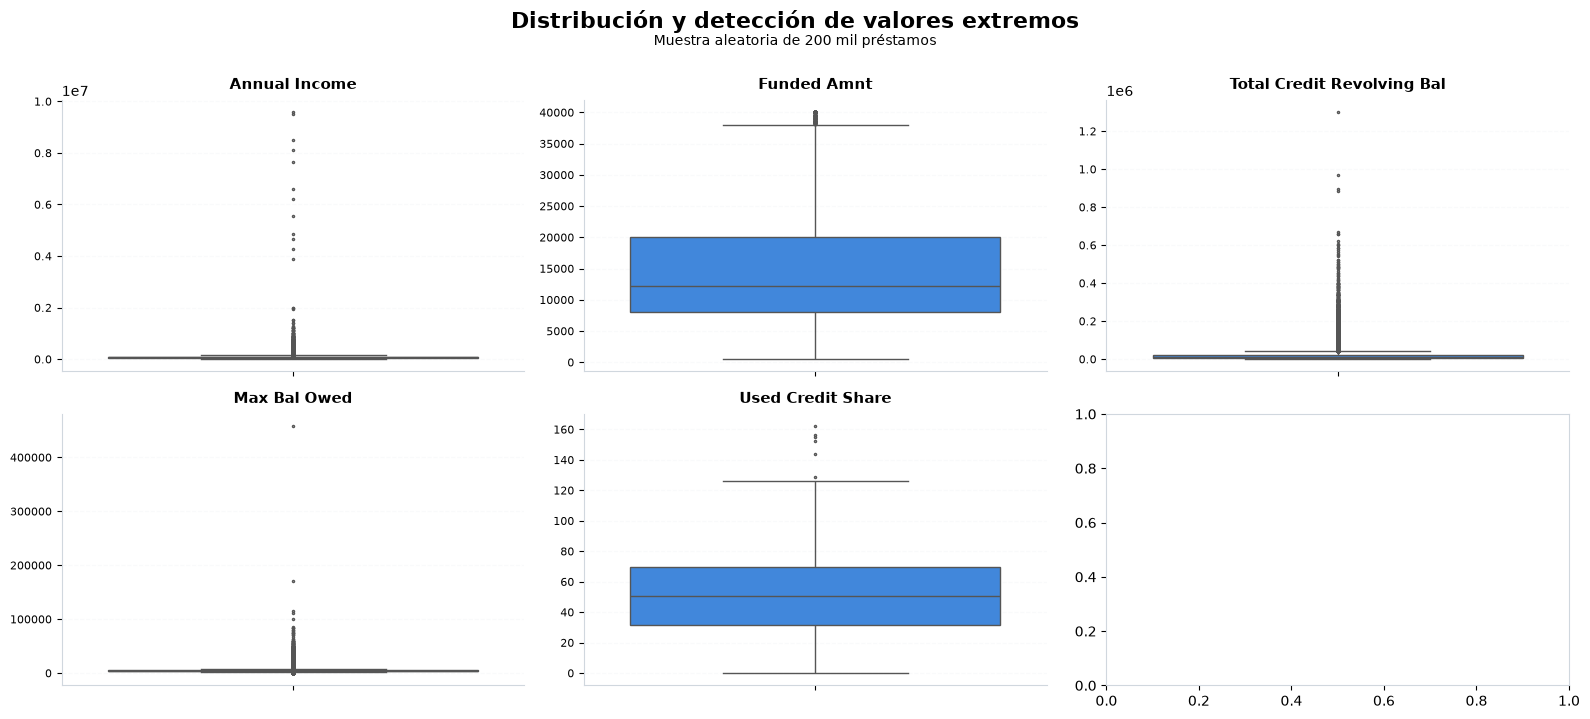

In [28]:
# Muestra para visualización
sample_box = (
    X_train.select(outlier_candidates)
      .sample(n=200_000, seed=RANDOM_STATE)
      .to_pandas()
)

fig, axes = plt.subplots(
    2, 3,
    figsize=(16, 7)
)

for ax, col in zip(axes.flat, outlier_candidates):

    sns.boxplot(
        y=sample_box[col],
        ax=ax,
        color="#2784F5",
        fliersize=1.5,
        linewidth=1
    )

    # Título
    ax.set_title(
        col.replace("_", " ").title(),
        fontsize=11,
        fontweight="bold",
        pad=8
    )

    # Ejes
    ax.set_ylabel("")

    # Grid
    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.20
    )
    ax.set_axisbelow(True)

    # Limpiar bordes
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Ticks
    ax.tick_params(
        axis="both",
        labelsize=8
    )

plt.suptitle(
    "Distribución y detección de valores extremos",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

fig.text(
    0.5,
    0.97,
    "Muestra aleatoria de 200 mil préstamos",
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()



In [29]:

X_train[[ "annual_income",
    "total_credit_revolving_bal",
    "max_bal_owed"]].describe()

statistic,annual_income,total_credit_revolving_bal,max_bal_owed
str,f64,f64,f64
"""count""",1.711714e6,1.711714e6,1.711714e6
"""null_count""",0.0,0.0,0.0
"""mean""",78970.022606,16642.06267,5228.324697
"""std""",122054.060402,22893.167196,4450.790844
"""min""",1900.0,0.0,0.0
"""25%""",47303.0,5985.0,3677.0
"""50%""",65136.0,11321.0,4403.0
"""75%""",95000.0,20197.0,5127.0
"""max""",1.1e8,2.904836e6,1.170668e6


In [30]:
# Obtenemos los limites inferiores de los poercentiles 0.005 y .0995
windosrize_vars = [
    "annual_income",
    "total_credit_revolving_bal",
    "max_bal_owed"
]

limites_winsor = {}

for col in windosrize_vars:
    limites_winsor[col] = {
        'lower' : X_train.select(pl.col(col).quantile(0.005)).item(),
        'upper': X_train.select(pl.col(col).quantile(0.995)).item(),
    }

limites_winsor

{'annual_income': {'lower': 15008.0, 'upper': 350000.0},
 'total_credit_revolving_bal': {'lower': 0.0, 'upper': 137147.0},
 'max_bal_owed': {'lower': 0.0, 'upper': 25816.0}}

In [31]:
# Funcion de winsorizacion
def windsorizar(df, columns, limites):
    expressions = []

    for col in columns:
        expressions.append(
            pl.col(col).clip(
                limites[col]['lower'],
                limites[col]['upper'])
            .alias(col)
        )
    
    return df.with_columns(expressions)

In [32]:
#plicamos a train y test
X_train = windsorizar(X_train, windosrize_vars, limites_winsor)

X_test = windsorizar(X_test, windosrize_vars, limites_winsor)

In [33]:
# Verificamos
X_train[windosrize_vars].describe()

statistic,annual_income,total_credit_revolving_bal,max_bal_owed
str,f64,f64,f64
"""count""",1.711714e6,1.711714e6,1.711714e6
"""null_count""",0.0,0.0,0.0
"""mean""",77666.505207,16208.377207,5185.449863
"""std""",47538.858797,17529.466591,3893.523891
"""min""",15008.0,0.0,0.0
"""25%""",47303.0,5985.0,3677.0
"""50%""",65136.0,11321.0,4403.0
"""75%""",95000.0,20197.0,5127.0
"""max""",350000.0,137147.0,25816.0


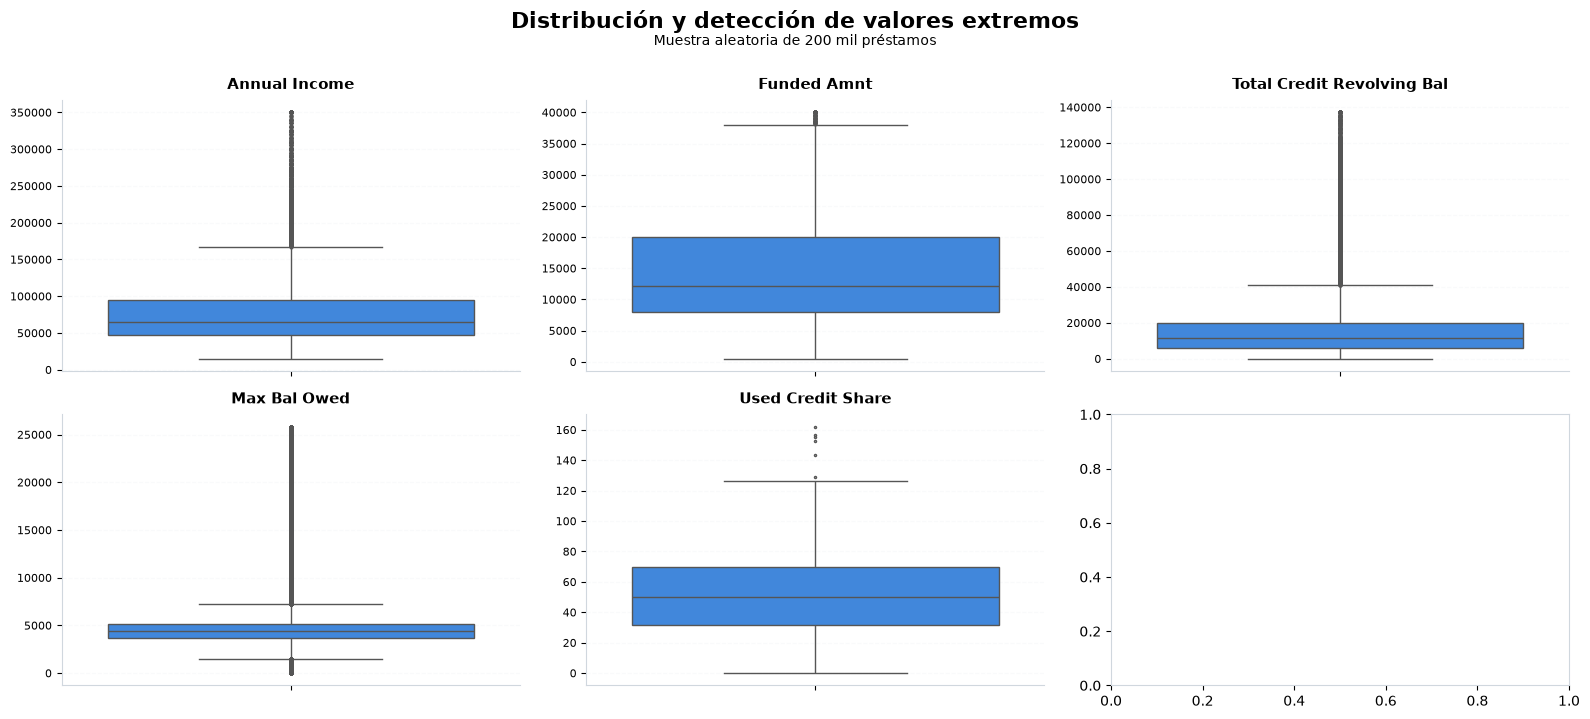

In [34]:

sample_box = (
    X_train.select(outlier_candidates)
      .sample(n=200_000, seed=RANDOM_STATE)
      .to_pandas()
)

fig, axes = plt.subplots(
    2, 3,
    figsize=(16, 7)
)

for ax, col in zip(axes.flat, outlier_candidates):

    sns.boxplot(
        y=sample_box[col],
        ax=ax,
        color="#2784F5",
        fliersize=1.5,
        linewidth=1
    )

    # Título
    ax.set_title(
        col.replace("_", " ").title(),
        fontsize=11,
        fontweight="bold",
        pad=8
    )

    # Ejes
    ax.set_ylabel("")

    # Grid
    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.20
    )
    ax.set_axisbelow(True)

    # Limpiar bordes
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Ticks
    ax.tick_params(
        axis="both",
        labelsize=8
    )

plt.suptitle(
    "Distribución y detección de valores extremos",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

fig.text(
    0.5,
    0.97,
    "Muestra aleatoria de 200 mil préstamos",
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()



## Ingeniera de variables

**Transformación logarítmica** de las variables monetarias con cola larga (`annual_income`, `funded_amnt`, `total_credit_revolving_bal`).


In [35]:
def crear_logs(df,columns):
    expressions = []

    for col in columns:
        expressions.append(
             pl.col(col)
        .log1p()
        .alias(f"log_{col}")
        )
    
    return df.with_columns(expressions)

In [36]:
log_vars = [
    "annual_income",
    "total_credit_revolving_bal",
    "max_bal_owed"
]

X_train = crear_logs(X_train, log_vars)
X_test = crear_logs(X_test, log_vars)

## VIF

Durante el EDA, observamos variables altamente correlacionadas. El VIF nos ayudará a filtrar que variables podriamos descartar.  

In [37]:
LOG_VARS = [
    "log_annual_income",
    "log_total_credit_revolving_bal",
    "log_max_bal_owed"]

In [38]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vars_vif = NUM + LOG_VARS

vif_sample = X_train.select(vars_vif).sample(n=150_000, seed=RANDOM_STATE).to_pandas()

def compute_vif(X: np.ndarray, cols: list[str]) -> pl.DataFrame:

    vifs = [variance_inflation_factor(X, i) for i in range(X.shape[1])]

    return pl.DataFrame({
        "variable": cols,
         "VIF": vifs}).sort("VIF", descending=True)

vif_table = compute_vif(vif_sample, list(vif_sample.columns))

with pl.Config(tbl_rows=-1, fmt_float="mixed"):
    print(vif_table)


shape: (32, 2)
┌────────────────────────────────────┬───────────┐
│ variable                           ┆ VIF       │
│ ---                                ┆ ---       │
│ str                                ┆ f64       │
╞════════════════════════════════════╪═══════════╡
│ funded_amnt                        ┆ 52.431276 │
│ monthly_payment                    ┆ 45.232859 │
│ log_annual_income                  ┆ 7.590649  │
│ annual_income                      ┆ 6.958383  │
│ loan_term_months                   ┆ 6.43813   │
│ num_rev_trades_op_in_12mths        ┆ 4.394746  │
│ num_rev_trades_op_in_24mths        ┆ 3.898772  │
│ mths_since_recent_revol_delinq     ┆ 3.669653  │
│ num_installment_acc_op_in_24mths   ┆ 3.583358  │
│ log_total_credit_revolving_bal     ┆ 3.296158  │
│ num_installment_acc_op_in_12mths   ┆ 3.25503   │
│ num_open_credit_lines              ┆ 2.682012  │
│ num_open_trades_in_6mths           ┆ 2.680153  │
│ mths_since_recent_bankcard_delinq  ┆ 2.612377  │
│ interest_rate 

`funded_amnt` y `monthly_payment` son las variables que tienen mayor multicolineadad VIF > 10. Esto es coherente ya que es una combinancion que depende uno del otro.  